# Radiative Heating and CWV Cross-Spectral Analysis

This notebook reproduces `Qr_CWV.ipynb` using the function-based workflow in `src/cross_spectrum_ana.py`. Each processing stage remains explicit.

In [ ]:
import sys
from pathlib import Path

import netCDF4 as nc
import numpy as np
from matplotlib import pyplot as plt

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import cross_spectrum_ana as workflow

## 1. NetCDF helper and configuration

In [ ]:
def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a NetCDF array to float and replace masks with NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

DATA_PATH = Path("/data92/b11209013")
OUTPUT_PATH = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_CWV_workflow")
LATITUDE_BOUNDS = (-5.0, 5.0)
WINDOW_SIZE = 96
OVERLAP_SIZE = WINDOW_SIZE // 2
MERIDIONAL_COMPONENT = "symmetric"
REFERENCE_KEY = "CWV"
SOURCE_NAME = "QR"
COHERENCE_LEVELS = (0.3, 0.4, 0.5, 0.6, 0.8)

## 2. Load data in the notebook

In [ ]:
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    latitude = as_float_array(dataset.variables["lat"][:])
    longitude = as_float_array(dataset.variables["lon"][:])
    latitude_mask = (latitude >= LATITUDE_BOUNDS[0]) & (latitude <= LATITUDE_BOUNDS[1])
    lw_heating = as_float_array(dataset.variables["column_LW"][:, latitude_mask, :])

with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    sw_heating = as_float_array(dataset.variables["column_SW"][:, latitude_mask, :])

with nc.Dataset(DATA_PATH / "ERA5_GRIB" / "Data" / "regrid" / "CWV.nc") as dataset:
    cwv_latitude = as_float_array(dataset.variables["lat"][:])
    cwv_longitude = as_float_array(dataset.variables["lon"][:])
    cwv_latitude_mask = (cwv_latitude >= LATITUDE_BOUNDS[0]) & (cwv_latitude <= LATITUDE_BOUNDS[1])
    cwv = as_float_array(dataset.variables["CWV"][:, cwv_latitude_mask, :])

source_fields = {"QR": lw_heating + sw_heating, "LW": lw_heating, "SW": sw_heating}
reference_field = cwv

## 3. Remove means and select the meridional component

In [ ]:
source_anomalies = {name: workflow.remove_time_zonal_mean(field) for name, field in source_fields.items()}
reference_anomaly = workflow.remove_time_zonal_mean(reference_field)

source_components = {
    name: workflow.select_meridional_component(field, MERIDIONAL_COMPONENT)
    for name, field in source_anomalies.items()
}
reference_component = workflow.select_meridional_component(reference_anomaly, MERIDIONAL_COMPONENT)
workflow.validate_aligned_fields(source_components, reference_component)

## 4. Segment the fields

In [ ]:
chunked_fields = workflow.segment_fields(
    {**source_components, REFERENCE_KEY: reference_component},
    window_size=WINDOW_SIZE,
    overlap_size=OVERLAP_SIZE,
)
source_chunks = {name: chunked_fields[name] for name in source_components}
reference_chunks = chunked_fields[REFERENCE_KEY]
n_segments, _, n_latitudes, n_longitudes = reference_chunks.shape
print(f"Windowed chunk shape: {reference_chunks.shape}")

Windowed chunk shape: (90, 96, 10, 360)


## 5. Calculate, average, and diagnose the spectra

In [ ]:
cross_spectrum, source_power, reference_power = workflow.calculate_segment_spectra(
    source_chunks, reference_chunks, window_size=WINDOW_SIZE
)
mean_cross, mean_source_power, mean_reference_power = workflow.average_segment_spectra(
    cross_spectrum, source_power, reference_power
)
diagnostics = workflow.calculate_spectral_diagnostics(
    mean_cross, mean_source_power, mean_reference_power
)
frequencies, zonal_wavenumbers = workflow.spectral_coordinates(WINDOW_SIZE, n_longitudes)

## 6. Prepare, generate, and save the figure

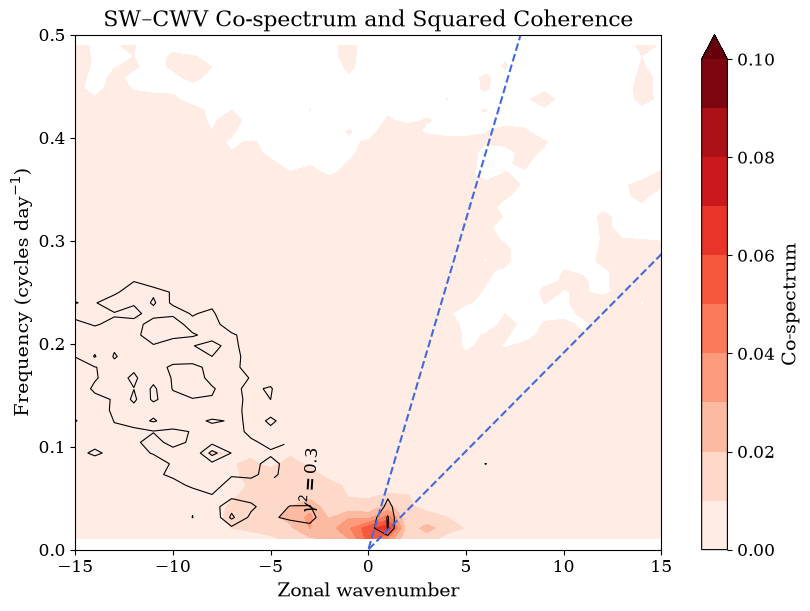

In [ ]:
plot_data = workflow.prepare_plot_data(
    frequencies,
    zonal_wavenumbers,
    diagnostics["normalized_cospectrum"][SOURCE_NAME],
    diagnostics["coherence_squared"][SOURCE_NAME],
)

plt.rcParams.update({"font.family": "serif", "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 16, "xtick.labelsize": 12, "ytick.labelsize": 12})
figure, axis = workflow.plot_cospectrum_with_coherence(
    *plot_data,
    source_name=SOURCE_NAME,
    reference_name=REFERENCE_KEY,
    shading_levels=np.linspace(-1.0, 1.0, 21), #type: ignore
    coherence_levels=COHERENCE_LEVELS,
    equivalent_depths=(8.0, 90.0),
    cmap="RdBu_r",
    extend="both",
    colorbar_label="Normalized co-spectrum",
)
axis.set_title(f"{SOURCE_NAME}–CWV Normalized Co-spectrum and Squared Coherence")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
figure.savefig(OUTPUT_PATH / f"{SOURCE_NAME}.png", dpi=600, bbox_inches="tight")
plt.show()